# Nonlinear Heat Conduction Problem with hyper-reduction, reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
import skrom.rom.deim.deim as deim_module
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation


In [4]:
# Control flag for expensive simulation generation

generate = False

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


---

## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

32


### Training Solution Snapshots


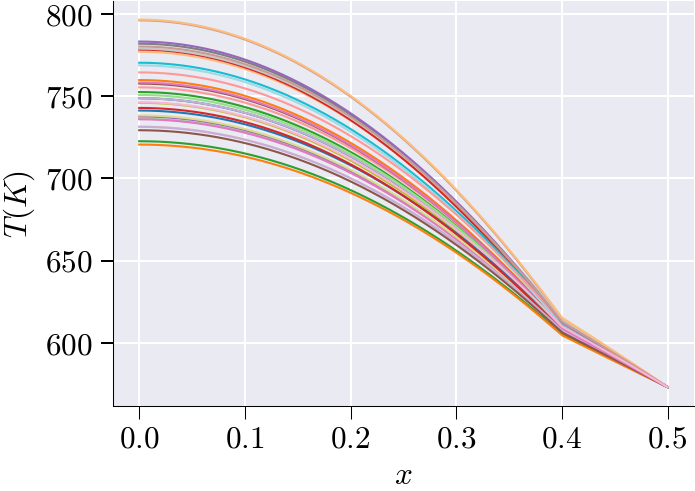

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

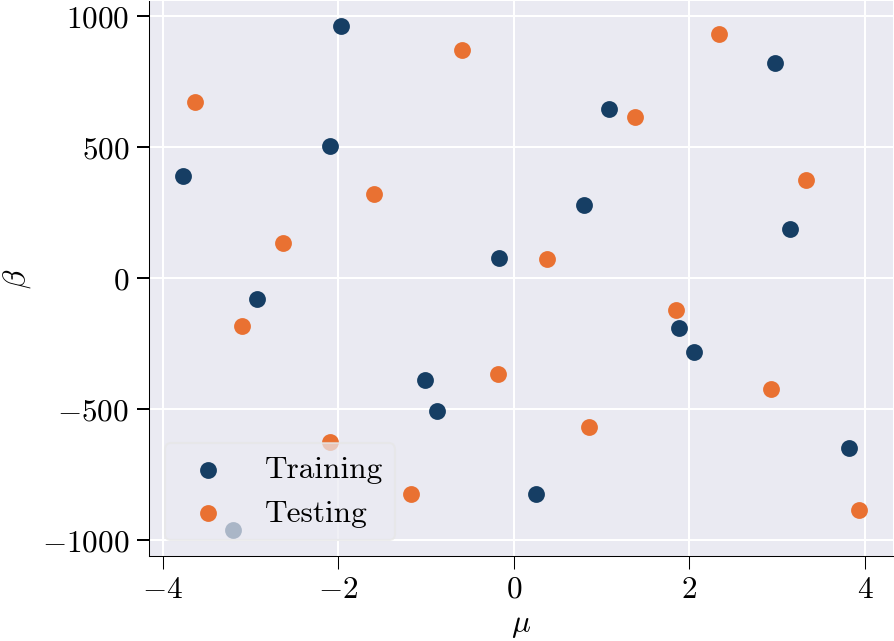

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Training Snapshots after mean subtraction

Text(0.5, 0, '$x$')

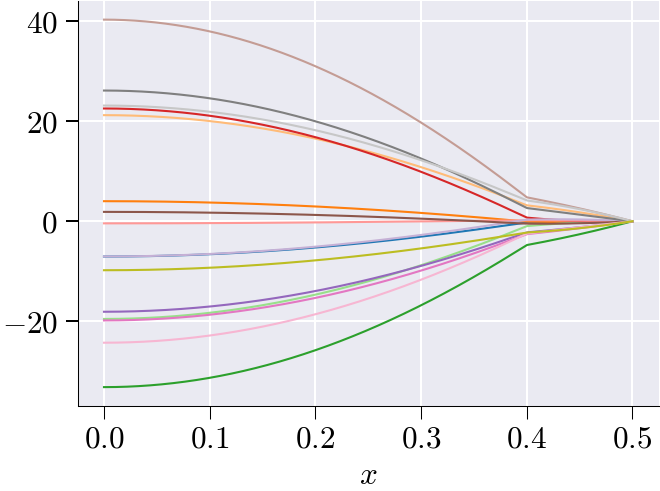

In [10]:
# Create figure with subplot for better control over the plot
fig, ax = plt.subplots(figsize=(5, 3.5))

# Apply the custom color cycle to this specific plot
# This ensures consistent coloring with the earlier defined palette


# Extract spatial coordinates (degrees of freedom locations) from the finite element basis
# These represent the x-coordinates where the temperature values are computed
mesh_domain = sim_data['basis'].item().doflocs[0]

# Plot all mean-centered temperature profiles from the training set
for i in range(len(NLS_train_ms)):
    # Plot each mean-centered temperature fluctuation profile
    # x-axis: spatial coordinate locations (DOF locations)
    # y-axis: temperature deviation from mean (fluctuations around zero)
    # Commented line shows alternative approach using different coordinate system
    # ax.plot(d.xi[0][:-1], LS_train_ms[i])
    ax.plot(mesh_domain, NLS_train_ms[i])

# Set x-axis label with mathematical formatting
plt.xlabel('$x$')  # Spatial coordinate

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

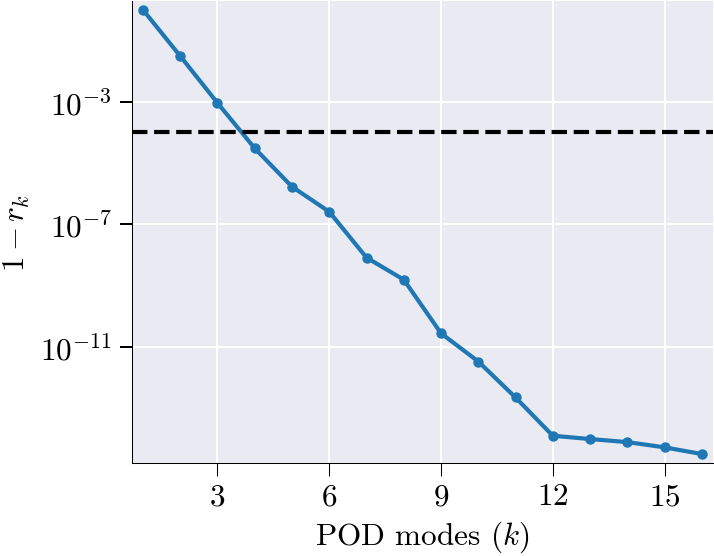

In [11]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-4,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

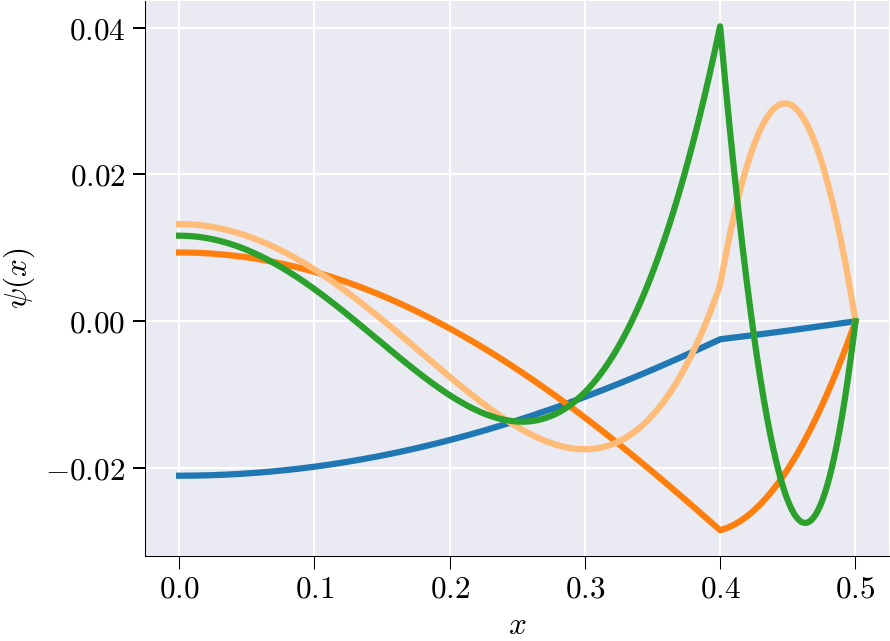

In [12]:
# Create figure and axis for POD modes visualization
fig, ax = plt.subplots()



# Plot all selected POD spatial modes
for i in range(n_sel):
    # Plot each POD mode as a function of spatial coordinate
    # x-axis: spatial locations (DOF coordinates)
    # y-axis: POD mode amplitude at each spatial location
    # lw=3: Use thick lines for better visibility of mode shapes
    plt.plot(mesh_domain, V_sel[:, i], lw=3)

# Set axis labels with mathematical notation
ax.set_xlabel('$x$')        # Spatial coordinate
ax.set_ylabel('$\\psi(x)$')  # POD mode amplitude (basis function value)

# Control the number of y-axis ticks for cleaner appearance
# nbins=5: Limit to approximately 5 major tick marks on y-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Display the plot
plt.show()

---

## ROM Simulation


In [13]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from d:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


In [14]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/32 params=[   1.85244951 -122.56331742]
[Newton] Iter  0, step norm = 9.268e+02
[Newton] Iter  1, step norm = 5.104e-01
[Newton] Iter  2, step norm = 2.329e-06
Snap 2/32 params=[ -1.58873209 320.13616711]
[Newton] Iter  0, step norm = 1.524e+03
[Newton] Iter  1, step norm = 5.561e+00
[Newton] Iter  2, step norm = 8.077e-05
Snap 3/32 params=[  -2.09780327 -626.47232227]
[Newton] Iter  0, step norm = 1.125e+02
[Newton] Iter  1, step norm = 4.953e-02
[Newton] Iter  2, step norm = 1.153e-09
Snap 4/32 params=[  2.33405532 933.41469206]
[Newton] Iter  0, step norm = 1.273e+03
[Newton] Iter  1, step norm = 3.362e+00
[Newton] Iter  2, step norm = 2.637e-05
Snap 5/32 params=[   3.93349164 -886.0525731 ]
[Newton] Iter  0, step norm = 1.031e+03
[Newton] Iter  1, step norm = 1.604e+00
[Newton] Iter  2, step norm = 5.615e-06
Snap 6/32 params=[ -3.63458695 672.85787873]
[Newton] Iter  0, step norm = 3.600e+03
[Newton] Iter  1, step norm = 3.540e+01
[Newton] Iter  2, step norm = 3.483e-03
Snap

In [15]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 6.0581e-04
Relative L2 Error:        4.9757e-08
L∞ Error:                 1.4042e-04
Relative L∞ Error:        1.7630e-07
RMSE:                     3.4127e-05
MAE:                      2.4343e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             2.6836e-07
95th Percentile Error:    6.8905e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.5054e-09
Max Rel L2 Error over time/parameter: 7.8251e-09
Min Rel L2 Error over time/parameter: 3.5994e-10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

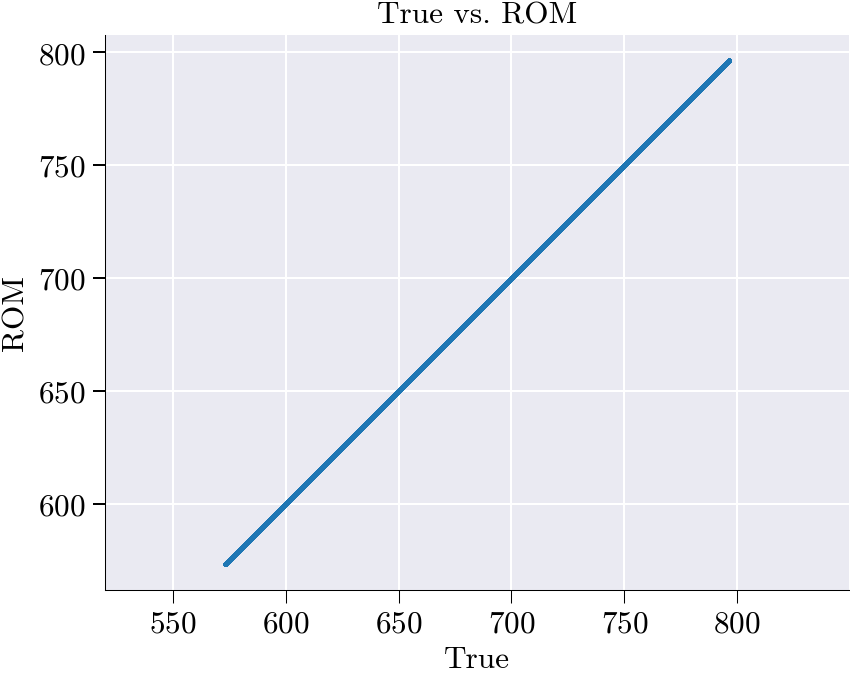

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


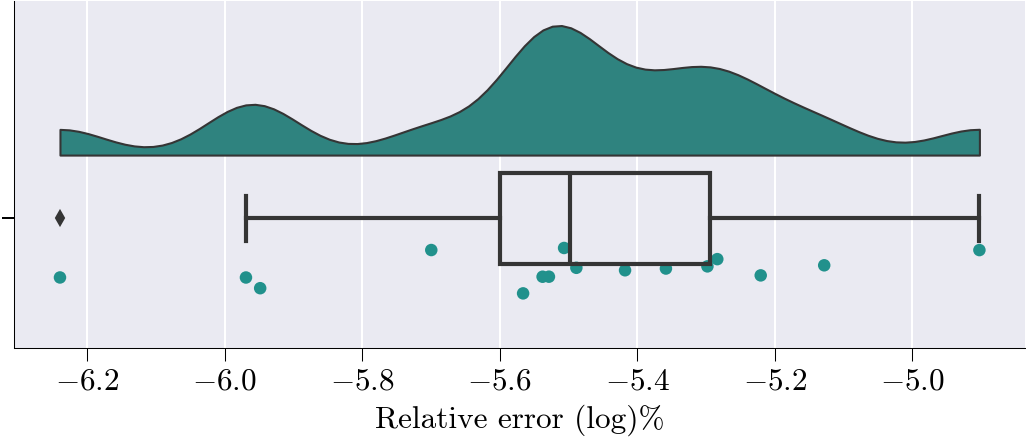

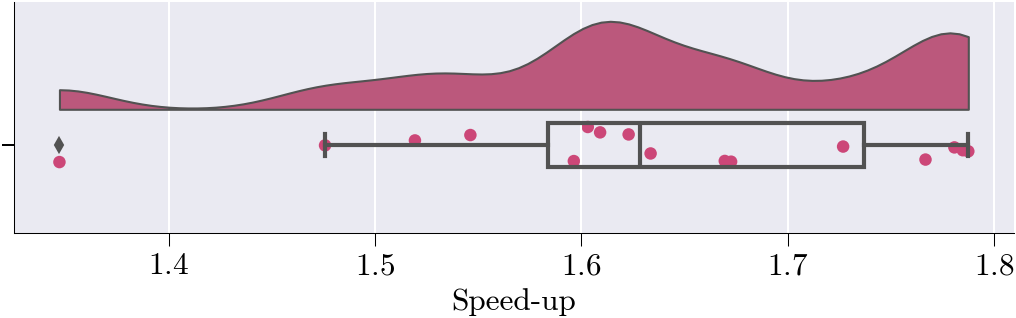

In [16]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


---

## Hyper ROM Simulation


### 1. ECSW

#### Mesh Sampling


In [17]:
prob = ProblemNonLinear()
sim_data['free_dofs'] = prob.domain()['free_dofs']
sim_data['dirichlet_boundary_dofs'] = prob.domain()['dirichlet_boundary_dofs']
sim_data['global_mask'] = prob.domain()['global_mask']
# Extract free degrees of freedom (DOFs) 
free_dofs = sim_data['free_dofs']
basis = sim_data['basis'].item()


In [18]:
# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [19]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
    training_params,
    prob.assemble_kwargs,
    extra_kwargs = dict(global_mask = sim_data['global_mask'] )
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(64, 5041)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 70.99999999992622


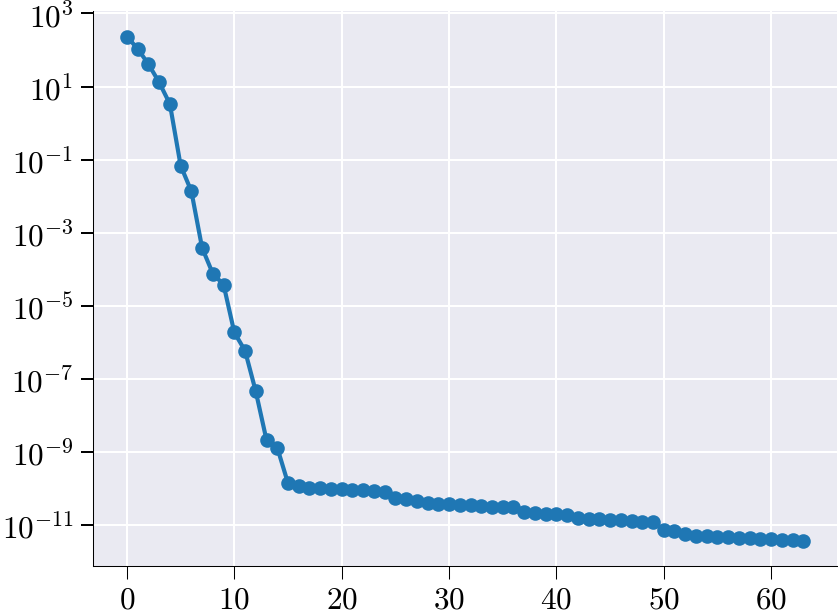

In [20]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:20]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [21]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 20 5041 0 7.034217105148348e+01 7.099999999992622e+01
1 1 20 5041 1 7.018078805633876e+01 7.086855392105247e+01
2 2 20 5041 2 6.971188613212875e+01 7.059966862765592e+01
3 3 20 5041 3 6.520806555807378e+01 6.839315257011485e+01
4 4 20 5041 4 6.238242631925726e+01 6.672155810716249e+01
5 5 20 5041 5 6.071203653582197e+01 6.580078931862977e+01
6 6 20 5041 6 5.664682167368151e+01 6.365442268803532e+01
7 7 20 5041 7 5.328089062476627e+01 6.199537790727862e+01
8 8 20 5041 8 4.658398109092573e+01 5.736098769587463e+01
9 9 20 5041 9 3.376839671447796e+01 4.983538410302487e+01
10 10 20 5041 10 2.621808921032334e+01 3.421671411442028e+01
11 11 20 5041 11 1.357887602229871e+01 2.212741975437655e+01
12 12 20 5041 12 1.364546214155895e+01 2.129002443069247e+01
13 13 20 5041 13 2.099907833149860e+00 4.721820482820130e+00
14 14 20 5041 14 1.752587157214067e+00 3.544356613040957e+00
15 15 20 5041 15 1.760088087176402e+00 3.0876102805680

#### Plot Reduced Meshes with weights

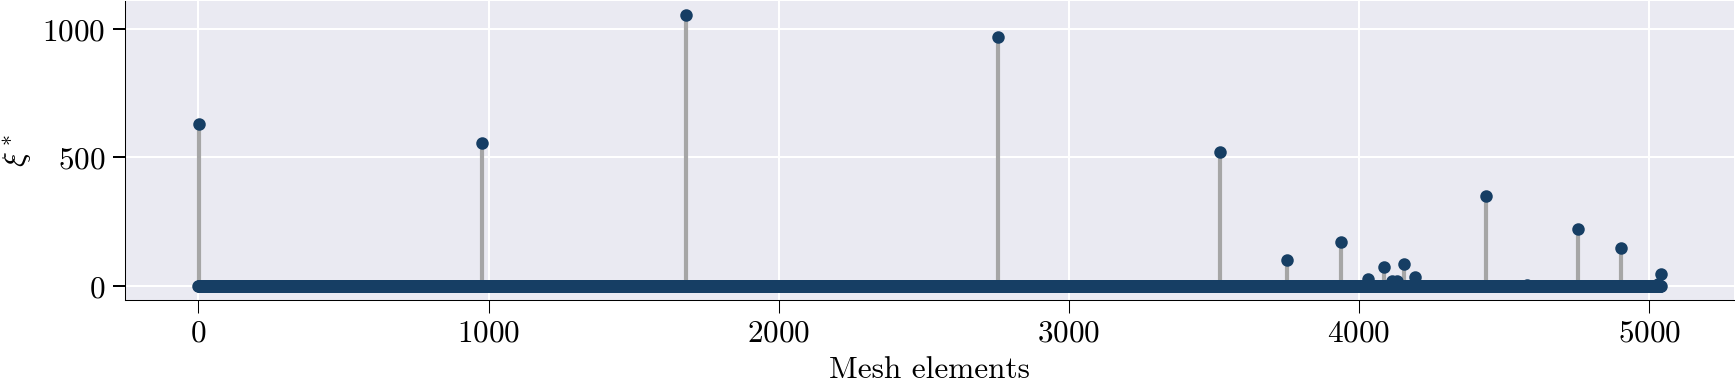

In [22]:
fig, ax = plot_ecsw_weights(x_nnls_m)

### Run HyperROM simulation


In [23]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
#rom will contain the hyper_rom solution as an attribute
rom.run_hyper_rom_simulation_ecsw(x_nnls_m);
#rom.run_hyper_rom_simulation(x_nnls_m)

Snap 1/32 params=[   1.85244951 -122.56331742]
[Newton] Iter  0, step norm = 7.466e+02
[Newton] Iter  1, step norm = 1.985e+01
[Newton] Iter  2, step norm = 3.299e-01
[Newton] Iter  3, step norm = 1.031e-02
[Newton] Iter  4, step norm = 1.712e-04
Snap 2/32 params=[ -1.58873209 320.13616711]
[Newton] Iter  0, step norm = 1.525e+03
[Newton] Iter  1, step norm = 1.374e+01
[Newton] Iter  2, step norm = 1.095e+00
[Newton] Iter  3, step norm = 1.214e-02
[Newton] Iter  4, step norm = 9.801e-04
Snap 3/32 params=[  -2.09780327 -626.47232227]
[Newton] Iter  0, step norm = 1.088e+02
[Newton] Iter  1, step norm = 4.415e+00
[Newton] Iter  2, step norm = 6.231e-02
[Newton] Iter  3, step norm = 4.541e-03
Snap 4/32 params=[  2.33405532 933.41469206]
[Newton] Iter  0, step norm = 1.281e+03
[Newton] Iter  1, step norm = 1.554e+01
[Newton] Iter  2, step norm = 6.019e-01
[Newton] Iter  3, step norm = 7.299e-03
Snap 5/32 params=[   3.93349164 -886.0525731 ]
[Newton] Iter  0, step norm = 1.028e+03
[Newton] 

In [24]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 6.0762e-04
Relative L2 Error:        4.9906e-08
L∞ Error:                 1.4097e-04
Relative L∞ Error:        1.7700e-07
RMSE:                     3.4228e-05
MAE:                      2.4587e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.6562e-06
95th Percentile Error:    6.8763e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.5411e-09
Max Rel L2 Error over time/parameter: 7.8198e-09
Min Rel L2 Error over time/parameter: 6.9271e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

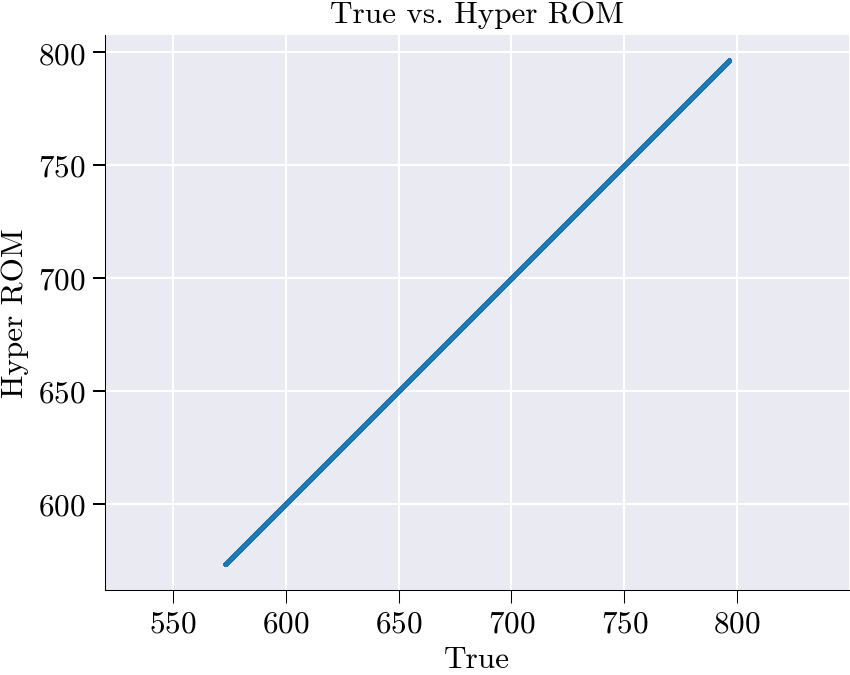

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


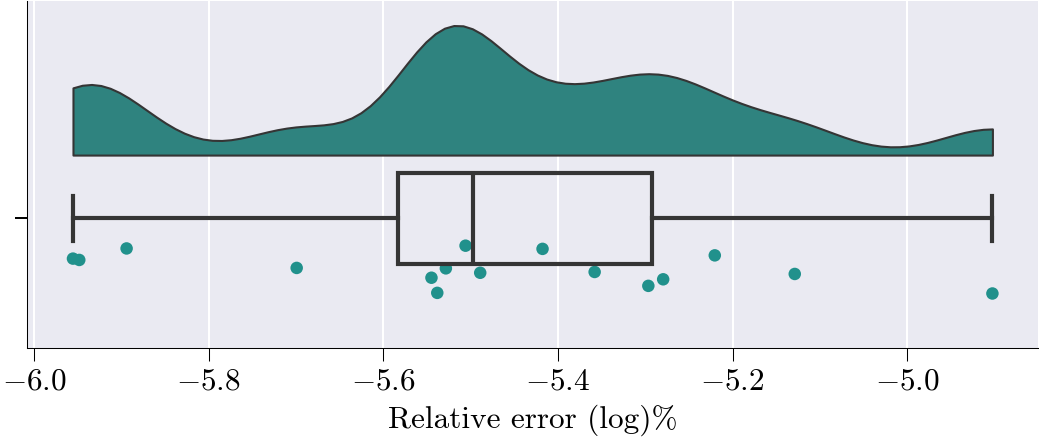

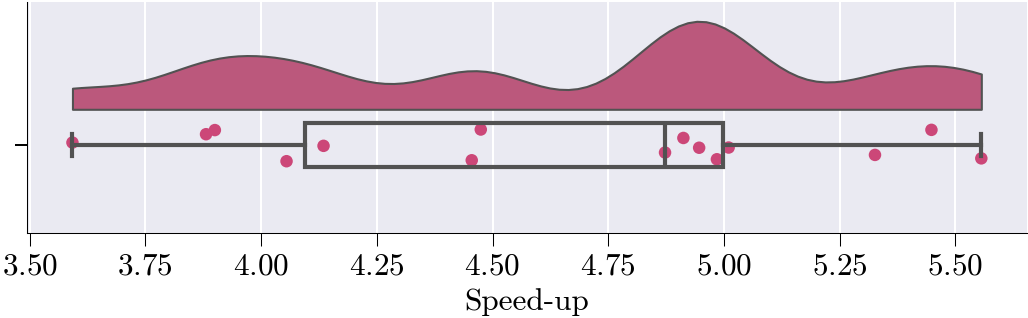

In [25]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)



---

### 2. DEIM

In [26]:
prob.basis = basis
prob.global_mask = sim_data['global_mask']
prob.mesh  = sim_data['mesh'].item()
F_nl = compute_nonlinear_snapshots(
    non_linear_func=prob.f_nl,
    fos_solutions=fos_solutions[train_mask],
    param_list=param_list[train_mask]
)

Text(0, 0.5, '$q(T,\\beta)$')

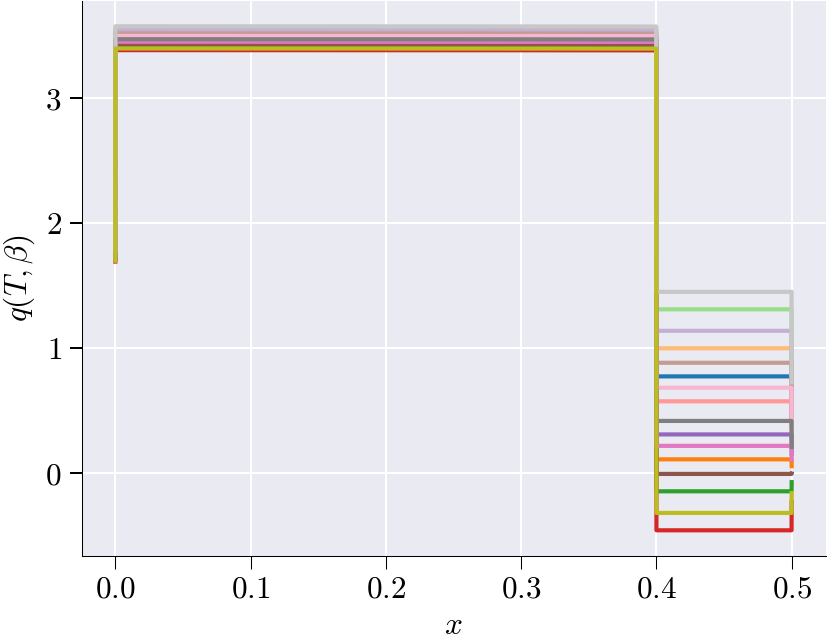

In [27]:
fig, ax = plt.subplots()
for i in range(len(F_nl)):
    ax.plot(mesh_domain, F_nl[i])
plt.xlabel('$x$')
plt.ylabel('$q(T,\\beta)$')

Selected modes:4


Text(0.5, 0, 'POD modes ($r$)')

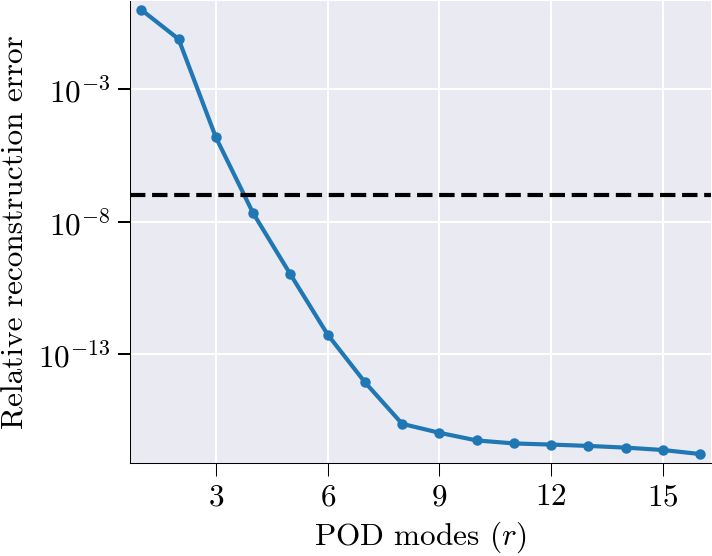

In [28]:
# Force snapshots
deim_class = deim_module.deim(prob.mesh, F_nl, V_sel, tol_f=1e-7, extra_modes = 0)

tic_h_setup_b = time.time()
deim_mat, sampled_rows = deim_class.select_elems()
toc_h_setup_b = time.time()

xi_deim = deim_class.xi
plt.xlabel('POD modes ($r$)')

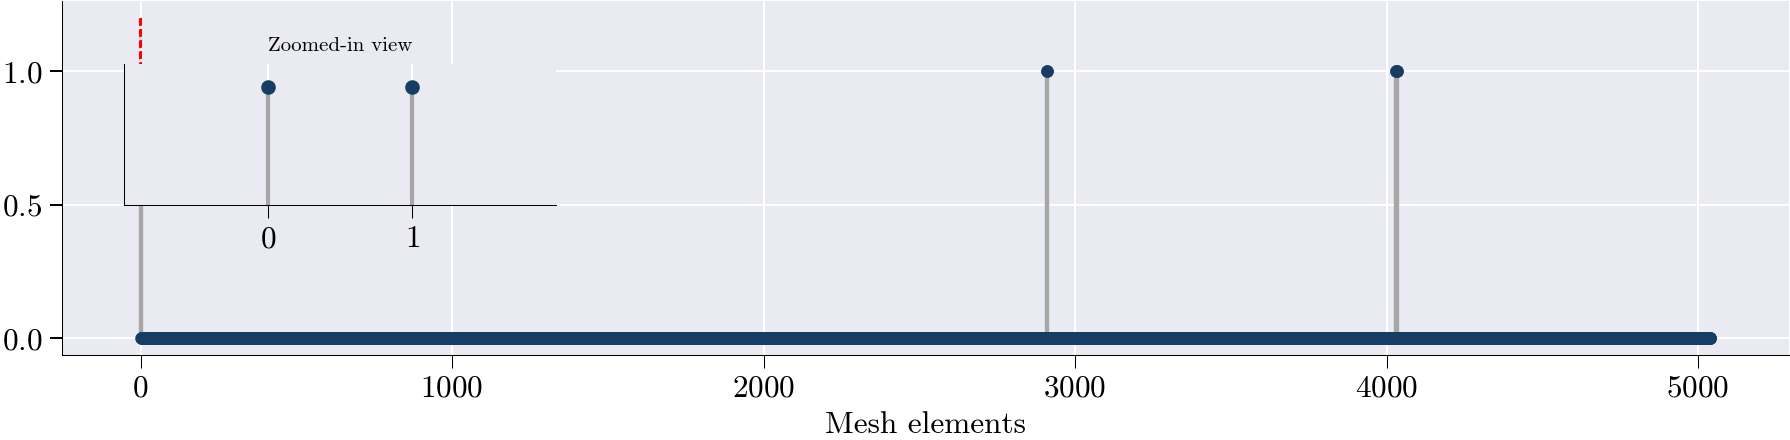

In [29]:
fig, ax = plot_deim_weights(xi_deim.copy())

In [30]:
rom.run_hyper_rom_simulation_deim(z = xi_deim, deim_mat = deim_mat, sampled_rows = sampled_rows);

Snap 1/32 params=[   1.85244951 -122.56331742]
[Newton] Iter  0, step norm = 8.889e+02
[Newton] Iter  1, step norm = 9.826e+02
[Newton] Iter  2, step norm = 5.468e+01
[Newton] Iter  3, step norm = 2.807e+00
[Newton] Iter  4, step norm = 4.684e-02
[Newton] Iter  5, step norm = 2.623e-02
[Newton] Iter  6, step norm = 5.685e-04
Snap 2/32 params=[ -1.58873209 320.13616711]
[Newton] Iter  0, step norm = 1.581e+03
[Newton] Iter  1, step norm = 7.839e+01
[Newton] Iter  2, step norm = 1.460e+01
[Newton] Iter  3, step norm = 2.303e+00
[Newton] Iter  4, step norm = 1.247e-01
[Newton] Iter  5, step norm = 1.307e-02
[Newton] Iter  6, step norm = 2.364e-03
Snap 3/32 params=[  -2.09780327 -626.47232227]
[Newton] Iter  0, step norm = 1.072e+02
[Newton] Iter  1, step norm = 6.391e+00
[Newton] Iter  2, step norm = 1.135e+00
[Newton] Iter  3, step norm = 2.197e-02
[Newton] Iter  4, step norm = 1.537e-02
[Newton] Iter  5, step norm = 4.391e-04
Snap 4/32 params=[  2.33405532 933.41469206]
[Newton] Iter  0

In [31]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 2.9423e-01
Relative L2 Error:        2.4166e-05
L∞ Error:                 4.8814e-02
Relative L∞ Error:        6.1288e-05
RMSE:                     1.6575e-02
MAE:                      1.2633e-02

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.1369e-13
95th Percentile Error:    4.5684e-02

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 1.1855e-06
Max Rel L2 Error over time/parameter: 3.9035e-06
Min Rel L2 Error over time/parameter: 1.1875e-07
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

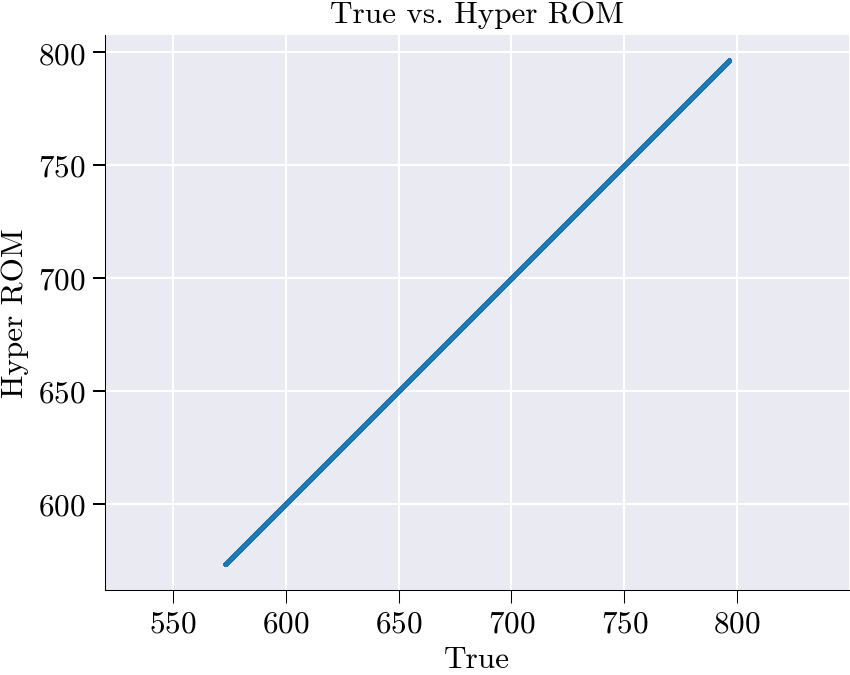

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


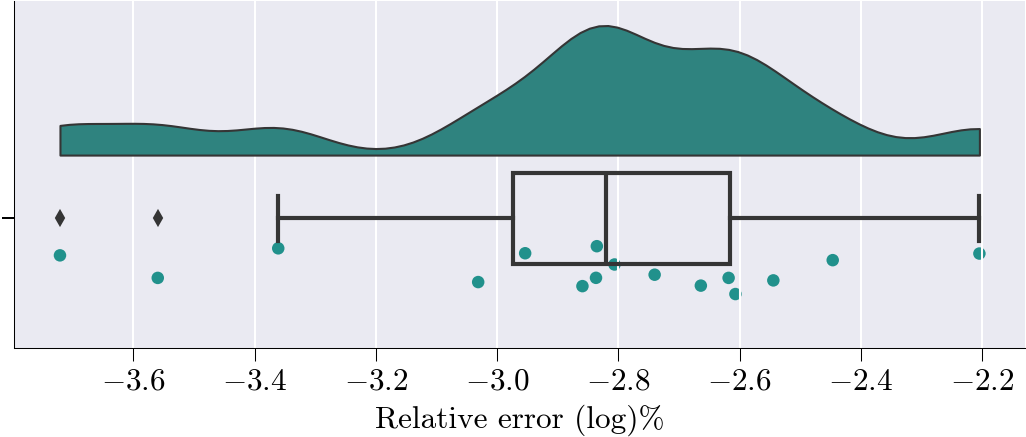

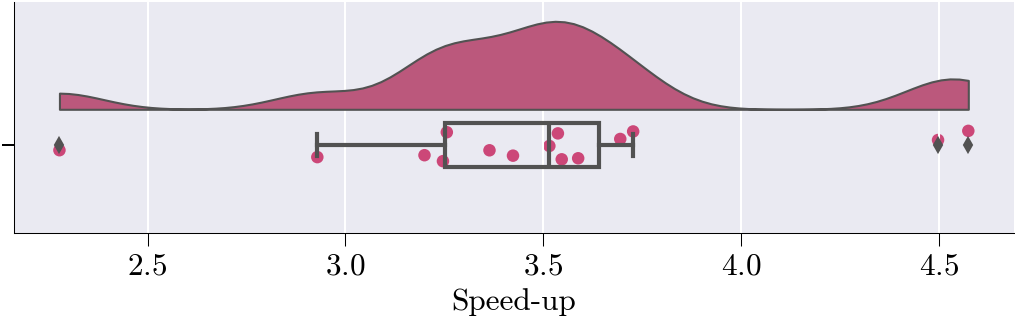

In [32]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)
